Training Linear...
Training RF...
Training SVR...
    Model       MAE      RMSE        R2
0  Linear  1.215263  1.412466 -0.006267
1      RF  1.239754  1.432262 -0.034670
2     SVR  1.217860  1.410176 -0.003007


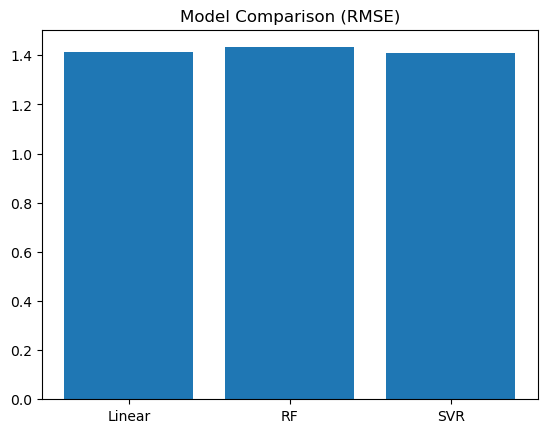

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv(r'C:\Users\vrund\Downloads\ML\amazon_sales_2025_INR.csv')

# Keep only numeric
df = df.select_dtypes(include=[np.number]).dropna()

# 🔥 Reduce size (VERY IMPORTANT for speed)
df = df.sample(n=min(5000, len(df)), random_state=42)

# Split
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔥 Scale data (needed for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized models
models = {
    "Linear": LinearRegression(),
    
    "RF": RandomForestRegressor(
        n_estimators=50,     # reduced
        max_depth=10,        # limit tree depth
        n_jobs=-1,
        random_state=42
    ),
    
    # 🔥 Use SMALL SVR only
    "SVR": SVR(
        kernel='rbf',
        C=1,
        epsilon=0.1
    )
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    if name == "SVR":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

# Save results
df_res = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
df_res.to_csv("RQ2_results.csv", index=False)

# Plot
plt.figure()
plt.bar(df_res["Model"], df_res["RMSE"])
plt.title("Model Comparison (RMSE)")


print(df_res)